# Objective 2: Activation Function Engineering

This notebook compares many FF activation functions, including Student-t negative log-density activations.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import torch

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from ff_research.experiments import run_activation_sweep
from ff_research.utils import seed_everything

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [2]:
seed_everything(42)

In [3]:
activation_candidates = [
    "relu",
    "leaky_relu",
    "elu",
    "selu",
    "gelu",
    "silu",
    "mish",
    "softplus",
    "tanh",
    "hardtanh",
    "softsign",
    "tanhshrink",
    "squareplus",
    "bent_identity",
    "student_t_nll_df2",
    "student_t_nll_df3",
    "student_t_nll_df5",
]
len(activation_candidates)

17

In [4]:
# Quick verification run before full sweep
smoke_rows = run_activation_sweep(
    activation_names=activation_candidates[:4],
    goodness_name="sum_sq",
    hidden_dims=(256, 256),
    epochs=1,
    batch_size=128,
    train_subset=3000,
    test_subset=1000,
    max_train_batches=8,
    max_eval_batches=3,
    device=device,
    seed=42,
)
pd.DataFrame(smoke_rows).sort_values("test_error")

,activation,goodness,train_loss,test_error,test_accuracy
2,elu,sum_sq,2.503729,0.809896,0.190104
0,relu,sum_sq,1.965020,0.825521,0.174479
1,leaky_relu,sum_sq,1.911708,0.848958,0.151042
3,selu,sum_sq,4.220972,0.880208,0.119792


In [5]:
# Full Objective 2 sweep
full_rows = run_activation_sweep(
    activation_names=activation_candidates,
    goodness_name="sum_sq",
    hidden_dims=(512, 512, 512),
    epochs=10,
    batch_size=128,
    train_subset=30000,
    test_subset=10000,
    max_train_batches=None,
    max_eval_batches=None,
    device=device,
    seed=42,
)
obj2_results = pd.DataFrame(full_rows).sort_values("test_error").reset_index(drop=True)
obj2_results

,activation,goodness,train_loss,test_error,test_accuracy
0,relu,sum_sq,0.557461,0.0737,0.9263
1,gelu,sum_sq,0.455380,0.0794,0.9206
2,silu,sum_sq,0.534094,0.0862,0.9138
3,leaky_relu,sum_sq,0.412336,0.0881,0.9119
4,student_t_nll_df5,sum_sq,0.515548,0.0891,0.9109
5,student_t_nll_df3,sum_sq,0.529816,0.0931,0.9069
6,student_t_nll_df2,sum_sq,0.541876,0.0955,0.9045
7,tanhshrink,sum_sq,0.661014,0.0968,0.9032
8,mish,sum_sq,0.574569,0.0988,0.9012
9,bent_identity,sum_sq,1.075029,0.1526,0.8474


In [6]:
obj2_results.to_csv(ROOT / "results_objective2_activation.csv", index=False)
obj2_results.head(10)

,activation,goodness,train_loss,test_error,test_accuracy
0,relu,sum_sq,0.557461,0.0737,0.9263
1,gelu,sum_sq,0.455380,0.0794,0.9206
2,silu,sum_sq,0.534094,0.0862,0.9138
3,leaky_relu,sum_sq,0.412336,0.0881,0.9119
4,student_t_nll_df5,sum_sq,0.515548,0.0891,0.9109
5,student_t_nll_df3,sum_sq,0.529816,0.0931,0.9069
6,student_t_nll_df2,sum_sq,0.541876,0.0955,0.9045
7,tanhshrink,sum_sq,0.661014,0.0968,0.9032
8,mish,sum_sq,0.574569,0.0988,0.9012
9,bent_identity,sum_sq,1.075029,0.1526,0.8474


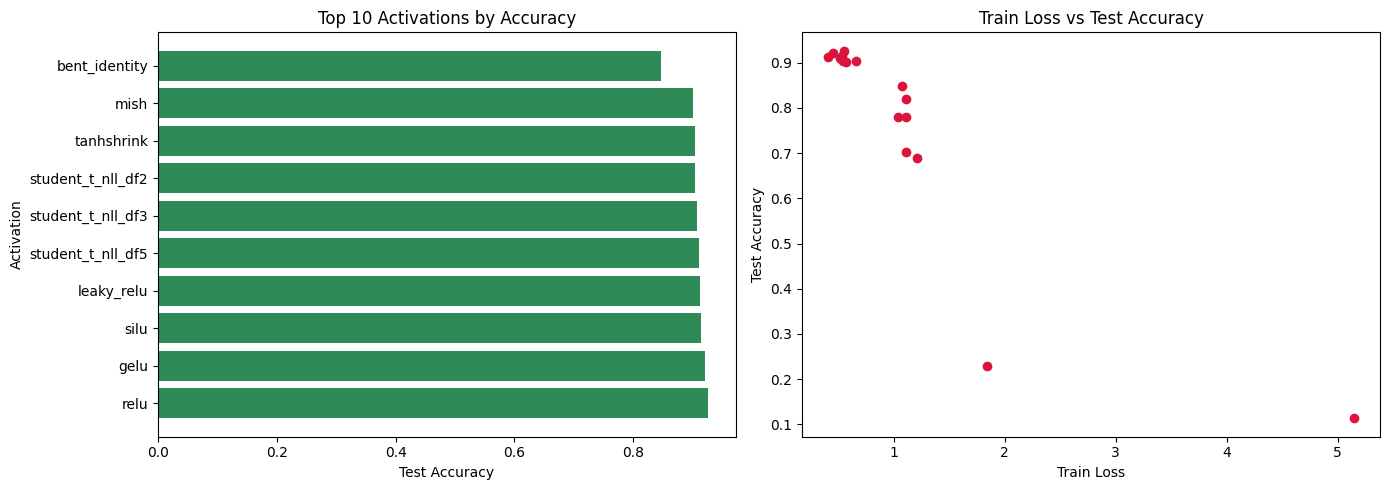

,activation,test_accuracy,test_error,train_loss
0,relu,0.9263,0.0737,0.557461
1,gelu,0.9206,0.0794,0.455380
2,silu,0.9138,0.0862,0.534094
3,leaky_relu,0.9119,0.0881,0.412336
4,student_t_nll_df5,0.9109,0.0891,0.515548
5,student_t_nll_df3,0.9069,0.0931,0.529816
6,student_t_nll_df2,0.9045,0.0955,0.541876
7,tanhshrink,0.9032,0.0968,0.661014
8,mish,0.9012,0.0988,0.574569
9,bent_identity,0.8474,0.1526,1.075029


In [7]:
import matplotlib.pyplot as plt

plot_df = obj2_results.copy()
top10 = plot_df.nsmallest(10, "test_error").sort_values("test_error", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10["activation"], top10["test_accuracy"], color="seagreen")
axes[0].set_title("Top 10 Activations by Accuracy")
axes[0].set_xlabel("Test Accuracy")
axes[0].set_ylabel("Activation")

axes[1].scatter(plot_df["train_loss"], plot_df["test_accuracy"], color="crimson")
axes[1].set_title("Train Loss vs Test Accuracy")
axes[1].set_xlabel("Train Loss")
axes[1].set_ylabel("Test Accuracy")


plt.tight_layout()
plt.show()

plot_df[["activation", "test_accuracy", "test_error", "train_loss"]].head(10)

## Visualization and Analysis

These charts highlight the best activations and the overall spread of outcomes.